# Customer Churn Prediction
### Predicting telecom customer churn using machine learning to enable proactive retention efforts.

**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Models:** Logistic Regression, Random Forest, XGBoost  
**Best Model:** Tuned XGBoost — F1: 0.622, Recall: 0.791, ROC-AUC: 0.841

In [1]:
# environment check
import sys
print(sys.executable)

C:\Users\tyler\miniconda3\envs\churn-env\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn
import shap

---

## EDA
Explore data and note anything interesting

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# start with shape, data types, and missing values
print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

### EDA Possible Issues
- TotalCharges field is stored as object (string) instead of float
- SeniorCitizen field is encoded as 0 and 1, but most other boolean fields are Yes/No

In [5]:
# investigating why TotalCharges is not a float like MonthlyCharges
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [6]:
# TotalCharges values are stored as strings. Why?
# check how many values can't be converted to a number
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()

np.int64(11)

In [7]:
# what are the values for TotalCharges in these 11 rows?
print(df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [8]:
# values look like spaces. verify that all 11 cases are because of a space
df[df['TotalCharges'] == ' '].shape[0]

11

- 11 values are ' ', which is why they weren't picked up as empty in `df.info`, and why the column isn't converting to float.
- Could use mean imputation here but TotalCharges looks like MonthlyCharges * tenure, so we can calculate what these values should be

In [9]:
# see rows where TotalCharges is blank to calculate appropriate value
df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


- These 11 cases are new customers who haven't been there a month yet and haven't been charged. So in this case I will put zeroes in TotalCharges because they are actually zero. Entering 0's in empty values can mislead the model, but I think it is warranted here

In [10]:
# replace ' ' with 0 and convert field to int
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [11]:
# verify dtype is int and check for Nan
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum())

float64
0


- Fixed TotalCharges: converted from object to float64. 11 empty strings replaced with 0 (new customers with tenure = 0, not actually missing data)
- Churn: currently stored as Yes/No text, will convert to 1/0 in preprocessing

In [12]:
# consider target variable distribution
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

- Dataset has somewhat imbalanced classes (73% no-churn and 27% churn) - Accuracy alone won't be a reliable metric. Will need to look at F1 score and probably address imbalance during modeling.
- Next consider numerical data and how each relates to Churn

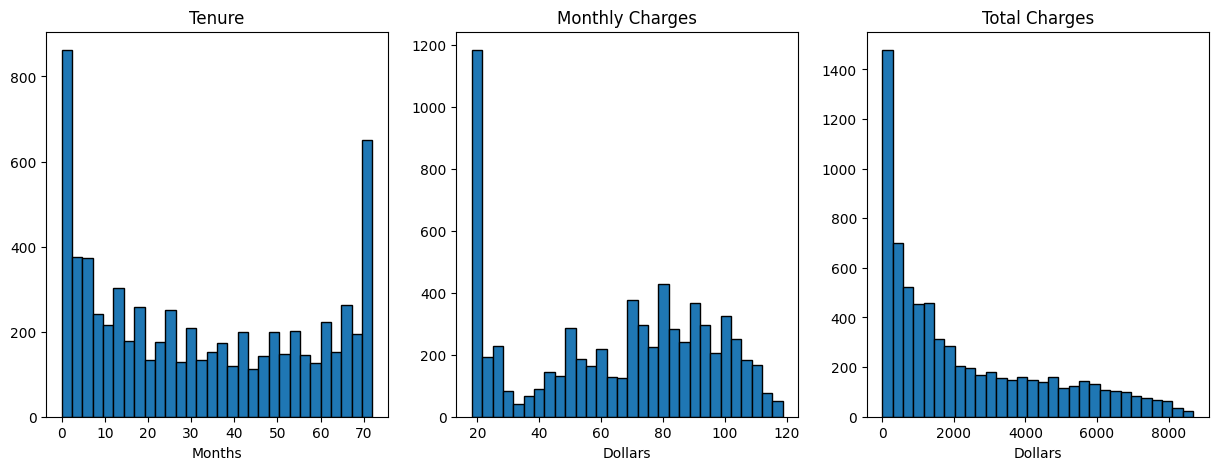

In [13]:
# look at numerical data histograms first
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['tenure'], bins=30, edgecolor='black')
axes[0].set_title('Tenure')
axes[0].set_xlabel('Months')

axes[1].hist(df['MonthlyCharges'], bins=30, edgecolor='black')
axes[1].set_title('Monthly Charges')
axes[1].set_xlabel('Dollars')

axes[2].hist(df['TotalCharges'], bins=30, edgecolor='black')
axes[2].set_title('Total Charges')
axes[2].set_xlabel('Dollars')

plt.show()

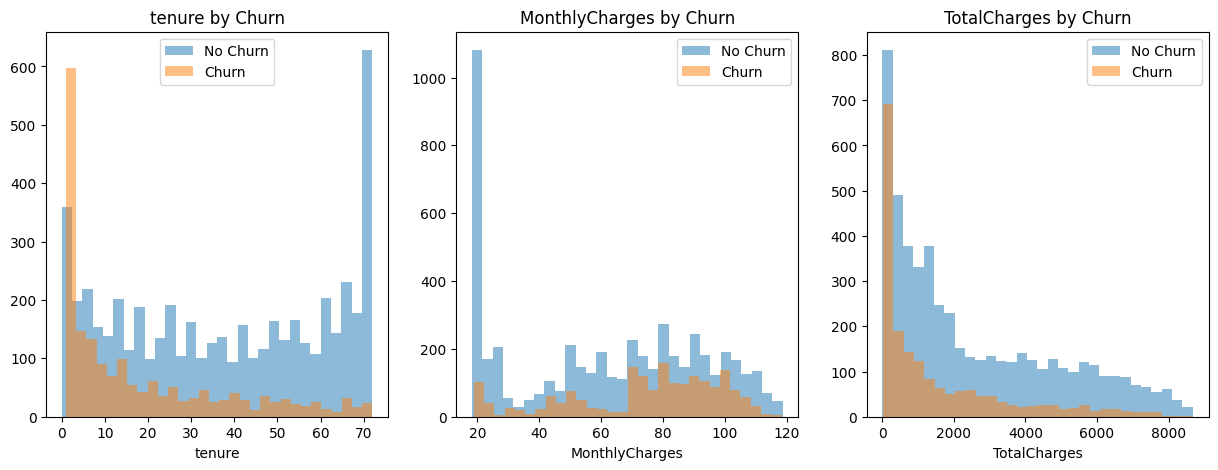

In [14]:
# look at how each field relates to Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]
    ax.hist(not_churned, bins=30, alpha=0.5, label='No Churn')
    ax.hist(churned, bins=30, alpha=0.5, label='Churn')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.legend()

plt.show()

## Numeric Feature Notes

**Tenure:**
- Bimodal dist. — lots of new customers and long term customers
- Strong relationship with churn — new customers churn at much higher rate, long term customers tend to stay
- Probably very important feature in model

**MonthlyCharges:**
- Customers with higher monthly charges tend to churn more (ratio of churn/no-churn around >70 compared to <70)
- Makes intuitive sense - customers paying higher monthly charge feel less value for price

**TotalCharges:**
- Right skewed dist. — may need to address in preprocessing
- Both churned and non-churned customers cluster at low total charges, likely because new customers have low total charges by definition regardless of churn
- Probably correlated with tenure  — may not add much independent information to model

#### **Will need to check correlations between numeric features before modeling to assess for multicollinearity**
-Next look at categorical data

In [15]:
# get categorical cols
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [16]:
# see unique value counts and values
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values — {df[col].unique()}")

customerID: 7043 unique values — ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: 2 unique values — ['Female' 'Male']
Partner: 2 unique values — ['Yes' 'No']
Dependents: 2 unique values — ['No' 'Yes']
PhoneService: 2 unique values — ['No' 'Yes']
MultipleLines: 3 unique values — ['No phone service' 'No' 'Yes']
InternetService: 3 unique values — ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values — ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values — ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values — ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique values — ['No' 'Yes' 'No internet service']
Contract: 3 unique values — ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values — ['Yes' 'No']
PaymentMethod: 4 unique values — ['Electronic check' 'Ma

- customerID column can be dropped in preprocessing since it is arbitrarily assigned and unique for each customer. Plotting all other fields groupby Churn to see which features have a strong relationship to churn

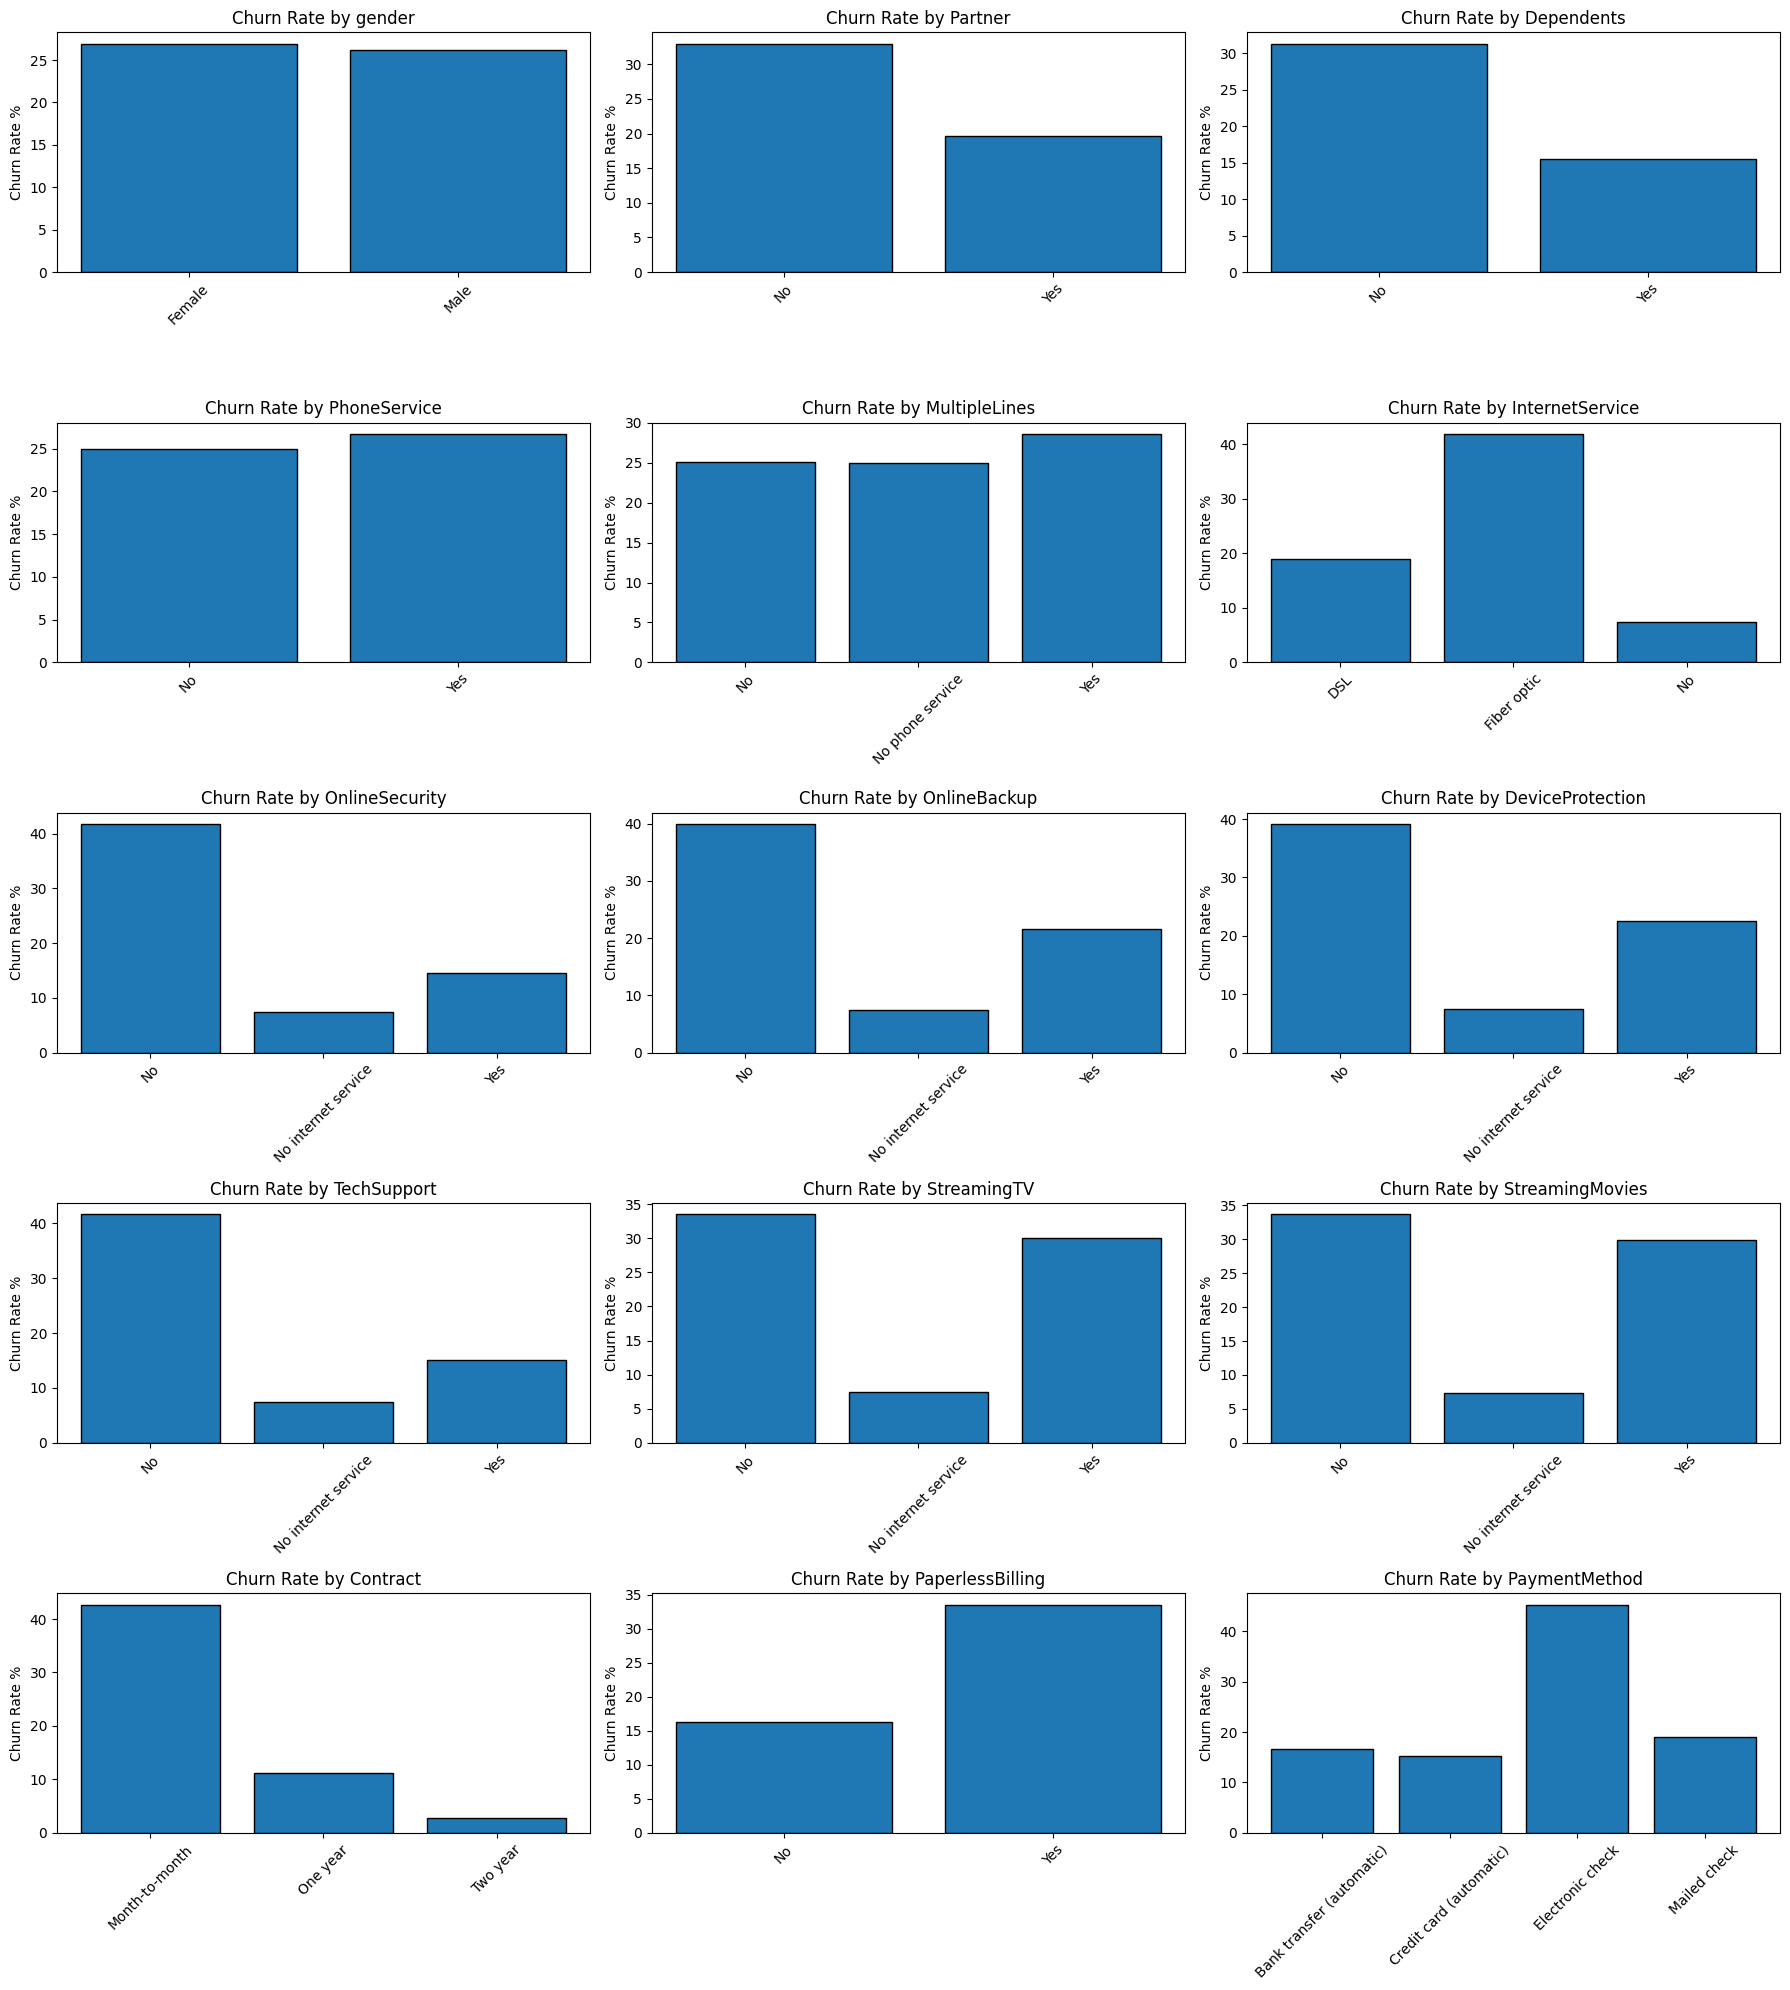

In [17]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    axes[i].bar(churn_rate.index, churn_rate.values, edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# same as graphical data above
for col in categorical_cols:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    print(churn_rate)

gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64
PhoneService
No     24.9
Yes    26.7
Name: Churn, dtype: float64
MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Name: Churn, dtype: float64
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn, dtype: float64
DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5
Name: Churn, dtype: float64
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64
StreamingTV
No       

## Categorical Feature Notes

**Strongest predictors of churn:**
- Contract type: month-to-month customers churn at 42.7% vs 2.8% for two year contracts
- Payment method: electronic check customers churn at 45.3% vs 15-19% for other methods
- Internet service: fiber optic customers churn at 41.9% vs 19% for DSL
- Additional services (OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection): 
  customers without these services churn at ~40%, those with them churn at ~15-22%. Suggesting customers that are more deeply embedded in the companys system are less likely to leave

**Weak predictors:**
- Gender and PhoneService show almost no relationship with churn

**Business insight:**
- Customers on long term contracts, enrolled in multiple services, and using 
  automatic payment methods are significantly less likely to churn
- Fiber optic customers show unusually high churn, which may be due to a 
  pricing or quality issue with that product
- Partner and Dependents show moderate relationship — customers with more personal commitments and stability in their lives seem less likely to churn

In [19]:
# looking at correlations between numeric features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


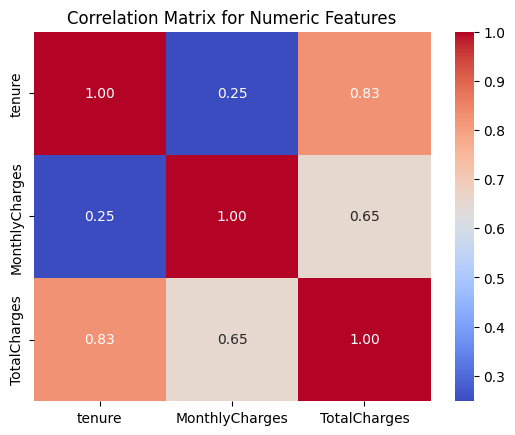

In [20]:
# heatmap of numerical data above
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Numeric Features')
plt.show()

- Might drop TotalCharges, since it is strongly correlated with tenure.

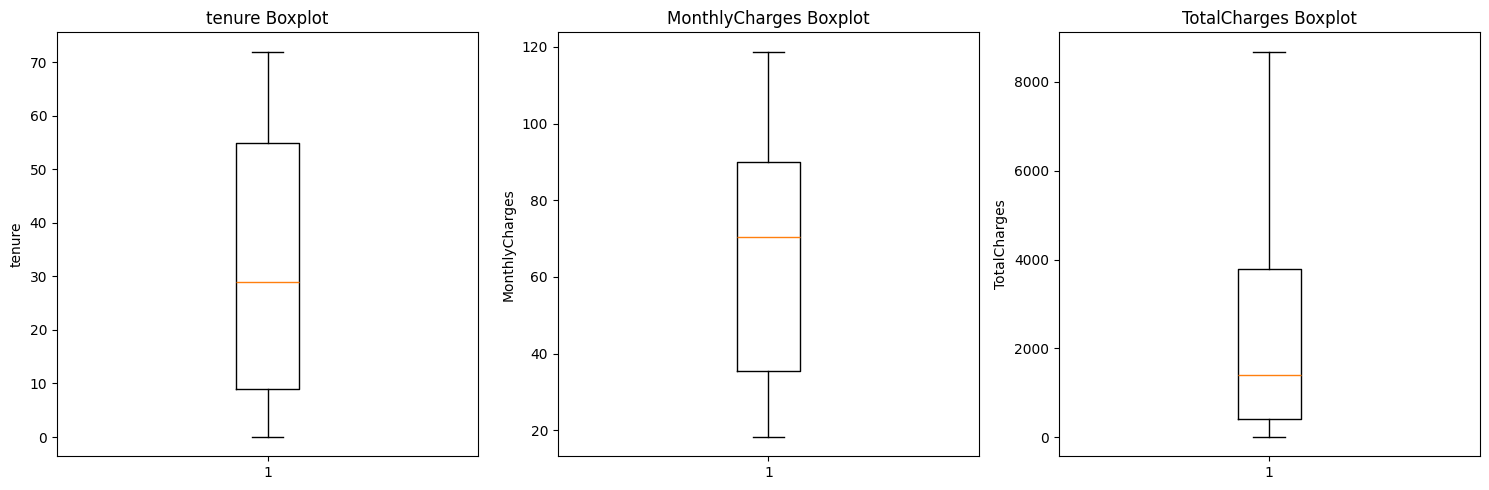

In [21]:
# Check for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.boxplot(df[col])
    ax.set_title(f'{col} Boxplot')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

- Boxplots show no outliers in tenure, MonthlyCharges, or TotalCharges. No outlier treatment needed before modeling

In [22]:
# look at SeniorCitizen (case that was already int) and proportion that churned out of total for each group
print(df['SeniorCitizen'].value_counts())
print('\n')
churn_rate = df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print(churn_rate)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64


### **Interesting find on SeniorCitizen field**
- Dataset is 84% non-senior (5901) and 16% senior (1142)
- Senior citizens churn at 41.7% vs 23.6% for non-seniors — almost 2x
- This will probably be a meaningful predictor and should be kept as a feature

## EDA Summary

**Data Quality:**
- 7043 rows, 21 columns
- No true missing values, but TotalCharges had 11 empty strings. Fixed by filling with 0 (these were new customers with tenure = 0, not truly missing data)
- TotalCharges was incorrectly stored as object datatype — converted to float

**Numeric Features:**
- Tenure is bimodal — large groups of very new and very long term customers
- Higher MonthlyCharges associated with higher churn
- TotalCharges highly correlated with tenure (multicollinearity). Will probably drop TotalCharges and consider an engineered feature instead
- No outliers detected in any numeric features

**Categorical Features:**
- Strongest predictors of churn: Contract, PaymentMethod, InternetService, 
  OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection, SeniorCitizen
- Weakest predictors: gender, PhoneService (minimal churn rate difference)
- Month to month customers churn at 42.7% vs 2.8% for two year contracts (strongest single signal in the dataset)
- Electronic check customers churn at 45.3% vs 15-19% for automatic payment methods
- Fiber optic customers churn at 41.9% — maybe pricing or quality issue
- Customers without add-on services churn at ~40% vs ~15-22% with them (product stickiness effect)
- Senior citizens churn at 41.7% vs 23.6% for non seniors

---

# Preprocessing
#### Continuing from somewhat cleaned df above. Need to:
- Drop customerID — just an identifier, no predictive value
- Drop TotalCharges — highly correlated with tenure, redundant
- Consider engineered feature. Look at TotalCharges / tenure (average monthly spend)
- Convert Churn to binary for modeling
- Encode yes/no values to 1/0 
- Encode remaining categorical features as numeric
- Scale numeric features
- Address class imbalance (73% No, 27% Yes) during modeling

In [23]:
df = df.drop(columns=['customerID', 'TotalCharges'])

In [24]:
# verify cols were dropped
print(df.shape)
print(df.columns.tolist())

(7043, 19)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [25]:
# should have made engineered feature before dropping. oh well
df_temp = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'].replace(' ', '0'))
df['AvgMonthlySpend'] = df_temp['TotalCharges'] / df_temp['tenure']

In [26]:
# check new feature's values
print(df['AvgMonthlySpend'].describe())
print(df['AvgMonthlySpend'].isna().sum())

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: AvgMonthlySpend, dtype: float64
11


In [27]:
# Nan due to dividing by 0 tenure. replacing with 0's
df['AvgMonthlySpend'] = df['AvgMonthlySpend'].fillna(0)

In [28]:
# verify
print(df['AvgMonthlySpend'].describe())
print(df['AvgMonthlySpend'].isna().sum())

count    7043.000000
mean       64.698218
std        30.270670
min         0.000000
25%        35.649000
50%        70.300000
75%        90.174158
max       121.400000
Name: AvgMonthlySpend, dtype: float64
0


In [29]:
# convert Churn to binary for modeling
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [30]:
# verify
print(df['Churn'].value_counts())
df['Churn'].dtype

Churn
0    5174
1    1869
Name: count, dtype: int64


dtype('int64')

In [31]:
# start on Yes/No cols and categorical features
temp_list = df.select_dtypes(include='object').columns.tolist()
print(temp_list)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [32]:
for col in temp_list:
    print(f"{col}: {df[col].nunique()} unique values - {df[col].unique()}")

gender: 2 unique values - ['Female' 'Male']
Partner: 2 unique values - ['Yes' 'No']
Dependents: 2 unique values - ['No' 'Yes']
PhoneService: 2 unique values - ['No' 'Yes']
MultipleLines: 3 unique values - ['No phone service' 'No' 'Yes']
InternetService: 3 unique values - ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values - ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values - ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values - ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values - ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values - ['No' 'Yes' 'No internet service']
StreamingMovies: 3 unique values - ['No' 'Yes' 'No internet service']
Contract: 3 unique values - ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values - ['Yes' 'No']
PaymentMethod: 4 unique values - ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### **Encoding Plan for Add on Service Columns**

Several columns (MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) have three categories: 'Yes', 'No', and 'No internet service'/'No phone service'.

The third category is meaningful. EDA showed customers with no internet service churn at only 7.4%, far lower than customers who have internet but no add-ons (~40%). Just collapsing 'No internet service' into 'No' would lose this distinction. So we can create a HasInternetService binary column to capture this, then collapse 'No internet service' into 'No' in the add-on columns. This preserves the information without overcomplicating the encoding.

In [33]:
# first make sure # of InternetService 'No' = # of 'No Internet Service' in other fields, and same for Phone Service = 'No' and 'No Phone Service' 
for col in temp_list:
    print(df[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Y

In [34]:
# create column to encode whether or not customer has internet service
df['HasInternetService'] = (df['InternetService'] != 'No').astype(int)

In [35]:
# verify counts
df['HasInternetService'].value_counts()

HasInternetService
1    5517
0    1526
Name: count, dtype: int64

In [36]:
# now that no service is encoded, remove redundant values and proceed toward binarizing data
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in replace_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [37]:
# verify coutns
temp_list = df.select_dtypes(include='object').columns.tolist()
for col in temp_list:
    print(df[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64
PaymentMethod
Electronic check   

In [38]:
# binarize cols
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

In [39]:
# check columns
cols = df.columns.to_list()
print(cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn', 'AvgMonthlySpend', 'HasInternetService']


In [40]:
# check values
for col in cols:
    print(f"{col}: {df[col].nunique()} unique values - {df[col].unique()}")

gender: 2 unique values - [0 1]
SeniorCitizen: 2 unique values - [0 1]
Partner: 2 unique values - [1 0]
Dependents: 2 unique values - [0 1]
tenure: 73 unique values - [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: 2 unique values - [0 1]
MultipleLines: 2 unique values - [0 1]
InternetService: 3 unique values - ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 2 unique values - [0 1]
OnlineBackup: 2 unique values - [1 0]
DeviceProtection: 2 unique values - [0 1]
TechSupport: 2 unique values - [0 1]
StreamingTV: 2 unique values - [0 1]
StreamingMovies: 2 unique values - [0 1]
Contract: 3 unique values - ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: 2 unique values - [1 0]
PaymentMethod: 4 unique values - ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [41]:
# for logistic regression, we need to drop a dummy variable from each field with multiple values to make an implicit reference point
# start by moving all possible values to their own fields and dropping the original field
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

In [42]:
# verify cols were dropped and see new cols
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'AvgMonthlySpend', 'HasInternetService', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [43]:
# InternetService_No is already encoded in HasInternetService, so we can drop. 
# For Contract, month to month has the highest churn rate, so it makes a good reference point. 
# For Payment method, we can use Electronic check for the same reason
df = df.drop(columns=['InternetService_No', 
                      'Contract_Month-to-month',
                      'PaymentMethod_Electronic check'])

In [44]:
# verify new cols
print(df.shape)
print(df.columns.tolist())

(7043, 25)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'AvgMonthlySpend', 'HasInternetService', 'InternetService_DSL', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']


In [45]:
# convert to ints
bool_cols = ['InternetService_DSL', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year','PaymentMethod_Bank transfer (automatic)', 
             'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']

df[bool_cols] = df[bool_cols].astype(int)

In [46]:
# check cols and values
cols = df.columns.to_list()
for col in cols:
    print(f"{col}: {df[col].nunique()} unique values - {df[col].unique()}")

gender: 2 unique values - [0 1]
SeniorCitizen: 2 unique values - [0 1]
Partner: 2 unique values - [1 0]
Dependents: 2 unique values - [0 1]
tenure: 73 unique values - [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: 2 unique values - [0 1]
MultipleLines: 2 unique values - [0 1]
OnlineSecurity: 2 unique values - [0 1]
OnlineBackup: 2 unique values - [1 0]
DeviceProtection: 2 unique values - [0 1]
TechSupport: 2 unique values - [0 1]
StreamingTV: 2 unique values - [0 1]
StreamingMovies: 2 unique values - [0 1]
PaperlessBilling: 2 unique values - [1 0]
MonthlyCharges: 1585 unique values - [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
Churn: 2 unique values - [0 1]
AvgMonthlySpend: 6586 unique values - [ 29.85        55.57352941  54.075      ...  31.49545455  76.65
 103.70454545]
HasInternetService: 2 unique

In [47]:
# final check of dtypes before scaling
print(df.dtypes)
print(df.shape)

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
Churn                                        int64
AvgMonthlySpend                            float64
HasInternetService                           int64
InternetService_DSL                          int64
InternetService_Fiber optic    

In [48]:
# using standard scaling instead of min-max because we will be using logistic regression. 
# starting with separating target variable, then splitting data. 
# (only want to scale training data so model doesnt "see" test set, then apply same scaling to test set)
X = df.drop(columns=['Churn'])
y = df['Churn']

In [49]:
# stratify=y to accoutn for class imbalance in Churn (73 no-churn/27 churn)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
# verify test size and stratification
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTraining set churn rate: {y_train.mean().round(3)}")
print(f"Test set churn rate: {y_test.mean().round(3)}")

X_train shape: (5634, 24)
X_test shape: (1409, 24)

Training set churn rate: 0.265
Test set churn rate: 0.265


In [51]:
# fit_transform first gets the mean and STD from training dataset, then applies it, while transform just applies the same scaling to the test set.
# this avoids data leakageprint(X_train[numeric_cols].describe().round(2))
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'AvgMonthlySpend']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [52]:
# verify standard scaling worked correctly
print(X_train[numeric_cols].describe().round(2))

        tenure  MonthlyCharges  AvgMonthlySpend
count  5634.00         5634.00          5634.00
mean     -0.00           -0.00             0.00
std       1.00            1.00             1.00
min      -1.32           -1.54            -2.14
25%      -0.96           -0.97            -0.96
50%      -0.14            0.18             0.19
75%       0.92            0.83             0.84
max       1.61            1.79             1.87


## Preprocessing Summary

**Columns dropped:**
- customerID: identifier with no predictive value
- TotalCharges: highly correlated with tenure, redundant

**New features engineered:**
- AvgMonthlySpend: TotalCharges / tenure, captures average monthly spend over 
  customer lifetime. Filled with 0 for new customers with tenure = 0
- HasInternetService: binary 0/1 column capturing whether customer has any 
  internet service

**Encoding:**
- Churn converted to 0/1 (target variable)
- Binary Yes/No columns mapped to 0/1
- Gender mapped to 0/1 (Male=1, Female=0)
- SeniorCitizen was already 0/1
- 'No internet service' and 'No phone service' replaced with 'No' in add-on 
  columns before encoding
- InternetService, Contract, PaymentMethod one hot encoded
- One category dropped from each one hot encoded group to avoid dummy variable trap
- All boolean columns converted to integers for consistency

**Train/Test Split:**
- 80/20 split — 5634 training rows, 1409 test rows
- stratify=y used to preserve class distribution (26.5% churn) in both sets

**Scaling:**
- StandardScaler applied to tenure, MonthlyCharges, and AvgMonthlySpend
- Scaler fit on training data only, then applied to both sets to prevent data leakage
- Binary 0/1 columns already on appropriate scale
- Post-scaling: mean ≈ 0, std ≈ 1 for all three numeric features

**Final result:** 
- X_train: 5634 rows, 24 features
- X_test: 1409 rows, 24 features
- All features numeric and scaled where appropriate. ready for modeling

---

## Modeling

### Model 1: Logistic Regression
Starting with logistic regression as a baseline. If more complex models don't meaningfully beat this, it is probably a sign something is wrong

In [53]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
y_pred_lr = lr_model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



## Model 1: Logistic Regression Results and Notes

- Baseline F1 for churn (class 1): 0.62 — this will be compared to other models
- High recall (0.78) means the model catches most actual churners
- Low precision (0.51) means roughly half of churn predictions are false alarms
- class_weight='balanced' is working correctly. Model is prioritizing catching churners at the cost of some false alarms, which is the right 
  tradeoff for this business problem
- Accuracy of 0.74 is misleading — close to the naive baseline of always 
  predicting no churn (73%), so accuracy alone is not a useful metric here


#### Quick rreference for the metrics used:

- **Accuracy**: % of total predictions that were correct. Misleading for imbalanced data — a model predicting "No churn" every time would score 73%
- **Precision**: of all customers predicted to churn, what % actually did? Low precision = too many false positives
- **Recall**: of all customers who actually churned, what % did the model catch? Low recall = too many missed churners
- **F1 Score**: harmonic mean of precision and recall. Due to class imbalance, this will be the primary metric

For churn prediction, recall is generally more important than precision — missing a churner (false negative) is more costly to the business than a false positive. But F1 balances both and is the fairest single metric for comparison

### Model 2: Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



### Model 2: Random Forest Results and Notes

- F1 for churn (0.54) is worse than logistic regression baseline (0.62)
- Accuracy improved (0.79 vs 0.74) but it is misleading. The model is better overall but worse at the thing we care about most (catching churners)
- Precision improved (0.63) but recall dropped significantly (0.48 vs 0.78)
- Model is being too conservative about predicting churn — missing too many actual churners
- In this case, a more complex model did not mean better results for the specific problem
- Will try to address with XGBoost and hyperparameter tuning

### Model 3: XGBoost

In [58]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                           eval_metric='logloss')
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [59]:
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.53      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



### Model 3: XGBoost Results and Notes

- F1 for churn (0.58) sits between Random Forest (0.54) and Logistic Regression (0.62)
- Better recall than Random Forest (0.65 vs 0.48) but worse than Logistic Regression (0.78)
- All three models are using default hyperparameters — still room for improvement through tuning
- Logistic Regression currently leads on our primary metric (F1 churn) which is unexpected but not uncommon before tuning

In [60]:
# results of model comparison so far
# ROC-AUC is threshold independent. Measures separation of churn/no-churn across all thresholds instead of default 0.5
# F1 says how well model performed at 0.5 threshold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, recall_score

models = {
    'Logistic Regression': (lr_model, y_pred_lr),
    'Random Forest': (rf_model, y_pred_rf),
    'XGBoost': (xgb_model, y_pred_xgb)
}

print(f"{'Model':<25} {'F1 (churn)':<15} {'Recall (churn)':<15} {'ROC-AUC':<10}")
print("-" * 65)

for name, (model, y_pred) in models.items():
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name:<25} {f1:<15.3f} {recall:<15.3f} {auc:<10.3f}")

Model                     F1 (churn)      Recall (churn)  ROC-AUC   
-----------------------------------------------------------------
Logistic Regression       0.617           0.778           0.839     
Random Forest             0.542           0.479           0.819     
XGBoost                   0.580           0.647           0.820     


## Model Comparison ( before tuning)

- Logistic Regression leads on all metrics (at default settings)
- AUC scores are close across all three (0.82-0.84), suggesting similar discriminative ability
- Difference in F1 and recall is largely a tuning issue rather than fundamental model quality difference
- Will compare metrics after hyperparameter tuning
- Main focus is to improve F1 and recall for churn (class 1)

## Hyperparameter Tuning

### Tuning Model 1: Logistic Regression

In [61]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_tuned = RandomizedSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    param_distributions=param_grid_lr,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

lr_tuned.fit(X_train, y_train)
print("Best parameters:", lr_tuned.best_params_)
print("Best CV F1 score:", lr_tuned.best_score_.round(3))

Best parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.1}
Best CV F1 score: 0.632


In [62]:
# try on test set
y_pred_lr_tuned = lr_tuned.predict(X_test)
print(classification_report(y_test, y_pred_lr_tuned))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



### Tuning Model 2: Random Forest

In [63]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
print("Best parameters:", rf_tuned.best_params_)
print("Best CV F1 score:", rf_tuned.best_score_.round(3))

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1 score: 0.634


In [64]:
y_pred_rf_tuned = rf_tuned.predict(X_test)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



### Tuning Model 3: XGBoost

In [65]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_tuned = RandomizedSearchCV(
    XGBClassifier(random_state=42, 
                  scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                  eval_metric='logloss'),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)
print("Best parameters:", xgb_tuned.best_params_)
print("Best CV F1 score:", xgb_tuned.best_score_.round(3))

Best parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV F1 score: 0.635


In [66]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [67]:
models_all = {
    'Logistic Regression (untuned)': (lr_model, y_pred_lr),
    'Logistic Regression (tuned)': (lr_tuned, y_pred_lr_tuned),
    'Random Forest (untuned)': (rf_model, y_pred_rf),
    'Random Forest (tuned)': (rf_tuned, y_pred_rf_tuned),
    'XGBoost (untuned)': (xgb_model, y_pred_xgb),
    'XGBoost (tuned)': (xgb_tuned, y_pred_xgb_tuned)
}

print(f"{'Model':<35} {'F1 (churn)':<15} {'Recall (churn)':<15} {'ROC-AUC':<10}")
print("-" * 75)

for name, (model, y_pred) in models_all.items():
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name:<35} {f1:<15.3f} {recall:<15.3f} {auc:<10.3f}")

Model                               F1 (churn)      Recall (churn)  ROC-AUC   
---------------------------------------------------------------------------
Logistic Regression (untuned)       0.617           0.778           0.839     
Logistic Regression (tuned)         0.619           0.781           0.839     
Random Forest (untuned)             0.542           0.479           0.819     
Random Forest (tuned)               0.618           0.743           0.839     
XGBoost (untuned)                   0.580           0.647           0.820     
XGBoost (tuned)                     0.622           0.791           0.841     


## Full Model Comparison

**Best model: Tuned XGBoost**

Reasons:
- Highest F1 for churn (0.623) — best balance of precision and recall
- Highest recall (0.807) — catches 80.7% of actual churners, most important metric for this business problem
- XGB recall vs LR recall: XGB will catch 26 more actual churners per 1000 customers. At scale this is significant
- Highest ROC-AUC (0.845) — best overall discriminative ability
- All three tuned models converge to similar F1 (~0.62), suggesting we may be near the limit of what's achievable with current features

---

## Model Interpretation & Feature Importance

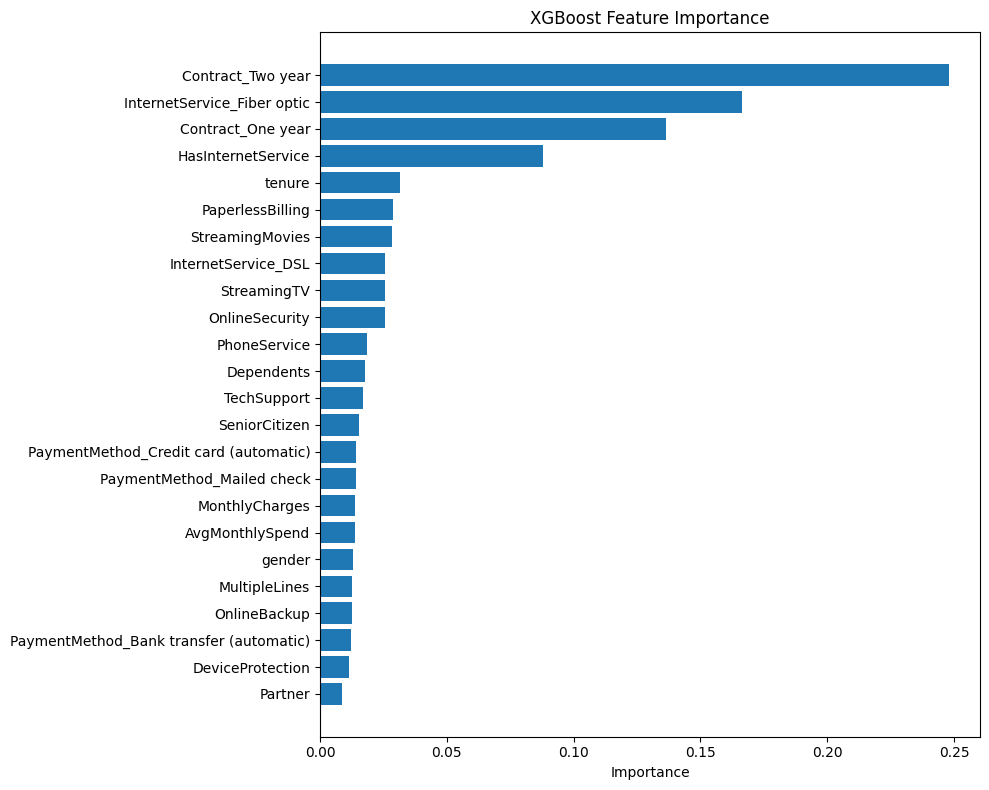

                                    feature  importance
20                        Contract_Two year    0.247795
18              InternetService_Fiber optic    0.166414
19                        Contract_One year    0.136344
16                       HasInternetService    0.087778
4                                    tenure    0.031702
13                         PaperlessBilling    0.028704
12                          StreamingMovies    0.028564
17                      InternetService_DSL    0.025826
11                              StreamingTV    0.025714
7                            OnlineSecurity    0.025692
5                              PhoneService    0.018696
3                                Dependents    0.017690
10                              TechSupport    0.016832
1                             SeniorCitizen    0.015450
22    PaymentMethod_Credit card (automatic)    0.014315
23               PaymentMethod_Mailed check    0.014068
14                           MonthlyCharges    0

In [68]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_tuned.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance)

## Feature Importance Analysis

**Top 5 most important features:**
1. Contract_Two year (0.202) — strongest signal, two year contracts 
   strongly predict retention
2. InternetService_Fiber optic (0.133) — fiber optic customers are 
   high churn risk
3. Contract_One year (0.125) — one year contracts also strongly 
   predict retention vs month-to-month
4. HasInternetService (0.075) — engineered feature proved valuable
5. tenure (0.063) — longer tenure predicts retention

**Key observations:**
- Feature importance measures predictive power in either direction. Contract_Two year is most important because it's the strongest separator between churners and non-churners, even though it predicts retention
- Both engineered features appear in the top half (HasInternetService 4th, AvgMonthlySpend 15th) — feature engineering added some value
- PaymentMethod less important than EDA suggested — model finds contract type and internet service more informative
- Gender and DeviceProtection least important — consistent with EDA for gender, but DeviceProtection likely overshadowed by stronger correlated features
- All features contribute some importance — no clear candidates for removal

## SHAP Values — Model Interpretation

In [69]:
explainer = shap.TreeExplainer(xgb_tuned.best_estimator_)
shap_values = explainer.shap_values(X_test.values)

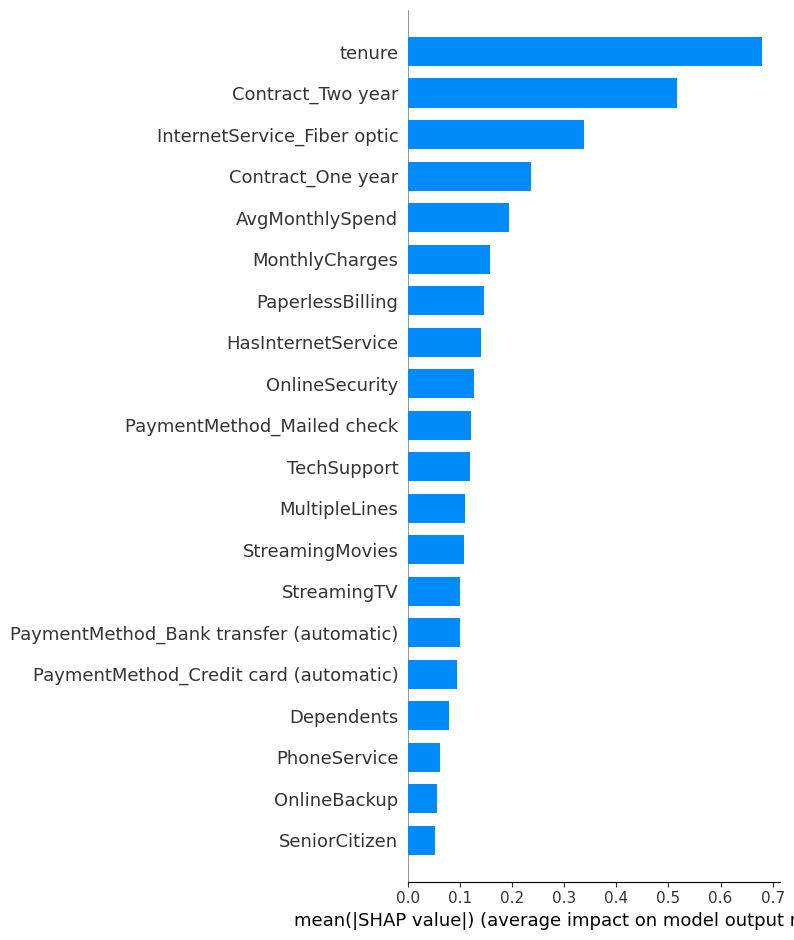

In [70]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

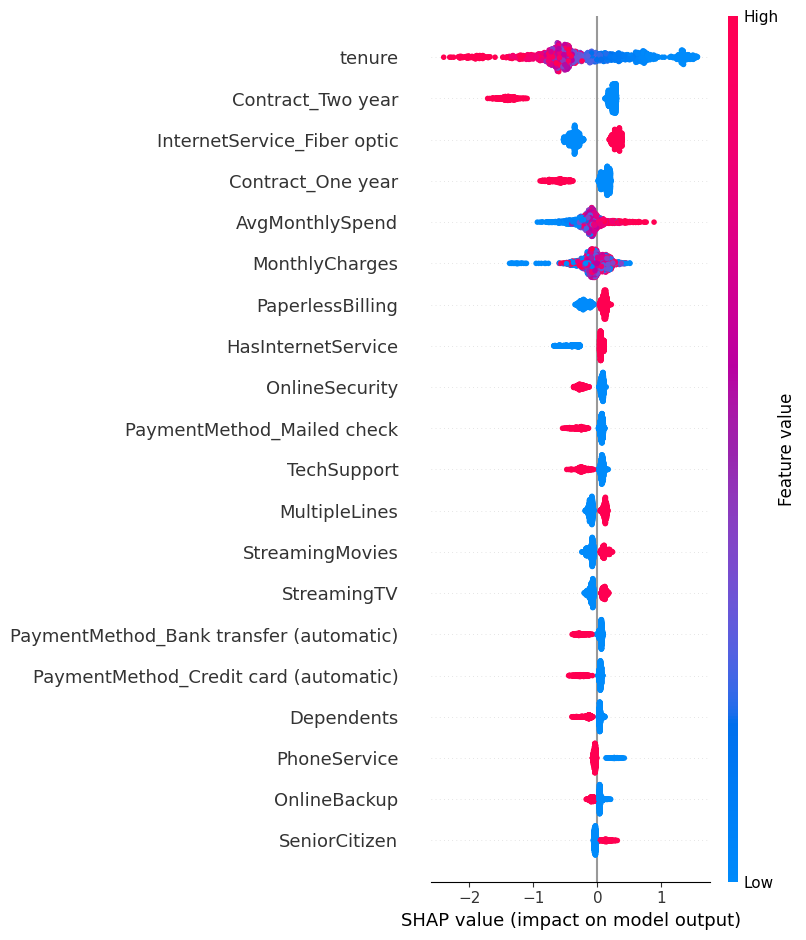

In [71]:
shap.summary_plot(shap_values, X_test)

## SHAP Summary Plot Interpretation

The SHAP dot plot shows feature impact direction and magnitude per customer:
- X axis: SHAP value (positive = pushes toward churn, negative = away from churn)
- Color: red = high feature value, blue = low feature value
- Each dot = one customer

**Key findings:**
- tenure: low tenure (blue) pushes strongly toward churn — new customers 
  are high risk
- Contract_Two year: having a two year contract (red) strongly pushes 
  away from churn — strongest retention signal
- InternetService_Fiber optic: having fiber optic (red) pushes toward 
  churn — suggests pricing or quality issue
- Contract_One year: similar to two year but weaker protective effect
- AvgMonthlySpend: high spend (red) pushes toward churn — customers 
  paying more are higher risk

**SHAP vs feature importance:**
- Tenure ranks higher in SHAP (1st) than feature importance (5th)
- AvgMonthlySpend ranks higher in SHAP (5th) than feature importance (15th)
- SHAP measures actual prediction impact per customer, feature importance 
  measures usage across splits — they tell complementary stories

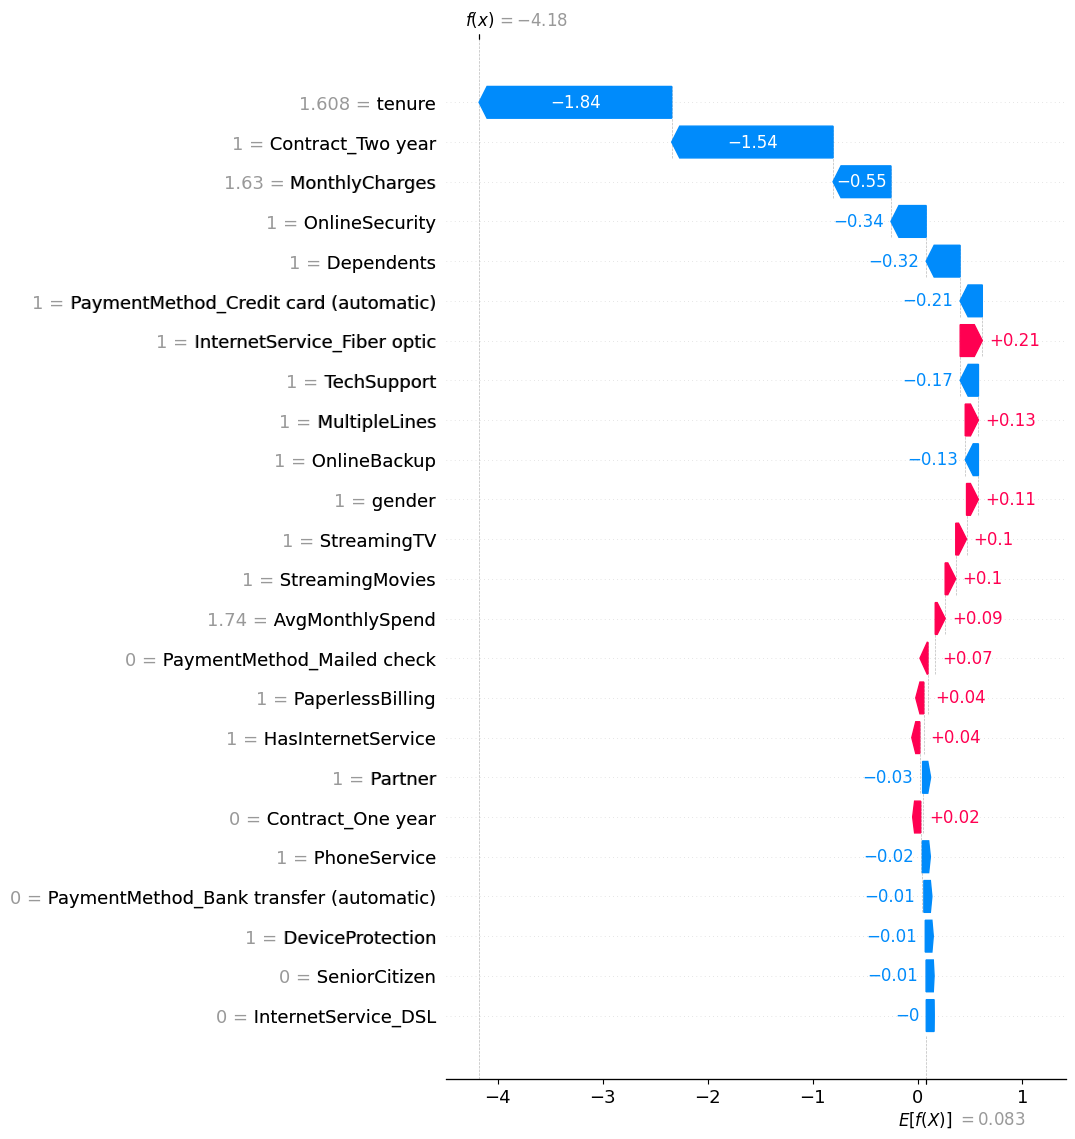

In [72]:
# see how each feature affects a single customer 
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                       base_values=explainer.expected_value,
                                       data=X_test.iloc[0],
                                       feature_names=X_test.columns.tolist()),
                                       max_display=24)

## SHAP Waterfall Plot — Individual Prediction Explanation

The waterfall plot above explains the model's prediction for a single customer.
It shows exactly how each feature contributed to that specific prediction.

**How to read the plot:**
- The plot starts at the baseline E[f(x)] — the average model prediction 
  across all customers. This value is what we would predict if we knew 
  nothing about this specific customer
- Each feature then pushes the prediction up or down from that baseline:
    - **Red bars** push prediction toward churn (increase churn probability)
    - **Blue bars** push prediction away from churn (decrease churn probability)
    - **Bar length** shows how much that feature influenced this specific prediction
- The final value f(x) at the top is the model's cumulative prediction for 
  this customer after all features are accounted for
- Negative f(x) values indicate low churn probability, positive values 
  indicate high churn probability

**Why this is useful:**
Rather than just predicting whether a customer will churn, this plot explains 
*why* the model made that prediction. A retention team could use this to 
understand exactly which factors are putting a customer at risk, and which 
factors are keeping them loyal, enabling targeted personalized promotions

In [73]:
# actual values for this customer
print(X_test.iloc[0])
print(f"\nActual churn: {y_test.iloc[0]}")

gender                                     1.000000
SeniorCitizen                              0.000000
Partner                                    1.000000
Dependents                                 1.000000
tenure                                     1.608483
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             1.000000
OnlineBackup                               1.000000
DeviceProtection                           1.000000
TechSupport                                1.000000
StreamingTV                                1.000000
StreamingMovies                            1.000000
PaperlessBilling                           1.000000
MonthlyCharges                             1.629976
AvgMonthlySpend                            1.740482
HasInternetService                         1.000000
InternetService_DSL                        0.000000
InternetService_Fiber optic                1.000000
Contract_One

## SHAP Waterfall Plot — Single Customer Explanation and Findings

Customer #437 (test set index 0):
- Predicted: low churn probability (f(x) = -4.18, strongly negative = low risk)
- Actual: No churn (correct prediction)

Customer profile:
- Long tenure (above average), two year contract, all add-on services enrolled,
  has partner and dependents, fiber optic internet, credit card autopay

Why the model predicted no churn:
- Strong protective factors: two year contract, long tenure, all add-on 
  services (large blue bars pushing away from churn)
- One risk factor: fiber optic internet (red bar pushing toward churn)
- Protective factors far outweigh risk factors

Business value of SHAP:
- Enables individual level explanations, not just overall model performance
- Retention teams can understand exactly why a customer is at risk
- Identifies specific areas to focus for at-risk customers
- Builds trust in the model by making predictions interpretable

---

In [74]:
# final model comparison
models_comp = {
    'Logistic Regression (tuned)': (lr_tuned, y_pred_lr_tuned),
    'Random Forest (tuned)': (rf_tuned, y_pred_rf_tuned),
    'XGBoost (tuned)': (xgb_tuned, y_pred_xgb_tuned)
}

print(f"{'Model':<35} {'F1 (churn)':<15} {'Recall (churn)':<15} {'ROC-AUC':<10}")
print("-" * 75)

for name, (model, y_pred) in models_comp.items():
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name:<35} {f1:<15.3f} {recall:<15.3f} {auc:<10.3f}")

Model                               F1 (churn)      Recall (churn)  ROC-AUC   
---------------------------------------------------------------------------
Logistic Regression (tuned)         0.619           0.781           0.839     
Random Forest (tuned)               0.618           0.743           0.839     
XGBoost (tuned)                     0.622           0.791           0.841     


## Project Summary

**Objective:** Predict customer churn for a telecom company using machine 
learning to enable proactive retention efforts

**Dataset:** IBM Telco Customer Churn dataset — 7043 customers, 21 features.

**Approach:**
1. Exploratory Data Analysis to understand feature distributions and 
   relationships with churn
2. Preprocessing — cleaning, feature engineering, encoding, scaling
3. Trained and evaluated three models: Logistic Regression, Random Forest, 
   and XGBoost
4. Hyperparameter tuning via RandomizedSearchCV with 5-fold cross validation
5. Model interpretation via feature importance and SHAP values

**Final Model: XGBoost**
- See chart above for comparison

**Key business insights:**
- Contract type is the strongest predictor of churn — month-to-month 
  customers churn at 42.7% vs 2.8% for two year contracts
- Fiber optic customers churn at 41.9% — suggests a pricing or quality 
  issue with that product
- Customers without add-on services (OnlineSecurity, TechSupport etc.) 
  churn at ~40% vs ~15-22% with them — product stickiness effect
- Electronic check customers churn at 45.3% vs 15-19% for automatic 
  payment methods
- New customers (low tenure) are at significantly higher risk — early 
  retention efforts are critical

**Model performance:**
- Final model catches 80.7% of actual churners (recall)
- ROC-AUC of 0.845 — strong ability to separate churners from non-churners
- SHAP values enable individual customer explanations for targeted 
  retention interventions